# Assignment 1 — training pipeline

You're using a notebook for this stage. If you'd rather use a script,
write `train.py` instead and delete this file — `main.py` refuses to run
if it finds both `train.py` and `train.ipynb`, so exactly one of them must
exist.

Replace this cell and everything below it with your own code. When run via
`uv run python main.py train`, this notebook must, start to finish, with
no manual steps in between:

- Load your committed dataset.
- Apply the feature engineering, preprocessing, and train/val/test split
  consistent with the business framing you wrote in `REPORT.md`.
- Train the same model — linear regression for a regression target,
  logistic regression for a binary one — three ways, on the same split:
  scikit-learn, a from-scratch PyTorch loop (Session 5's manual approach:
  raw tensors, autograd, a manual gradient-step update), and the standard
  `torch.nn.Module` + `torch.optim` workflow.
- Evaluate all three against each other and against a naive baseline.
- Save whatever `app.py`/`app.ipynb` needs to build its dashboard without
  retraining anything.

How you structure the code beyond that — cell layout, function
boundaries, naming — is your call to make and be able to defend.

In [2]:
   import pandas as pd
   df = pd.read_csv("data/dataset.csv")
   df.head()
   


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                             4424

In [3]:
df["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [6]:
df["is_dropout"] = (df["Target"] == "Dropout").astype(int)
df["is_dropout"].value_counts(normalize=True)

is_dropout
0    0.678797
1    0.321203
Name: proportion, dtype: float64

In [7]:
# Drop the original string target (already replaced by is_dropout) 
# and all 2nd-semester columns, since those represent info from after the prediction point (after 1st semester) and would leak the future.

df = df.drop(columns=["Target"])

sem2_cols = [col for col in df.columns if "2nd sem" in col]
df = df.drop(columns=sem2_cols)

print("Dropped columns:", sem2_cols)
print("New shape:", df.shape)

Dropped columns: ['Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)']
New shape: (4424, 29)


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 29 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                             4424

In [10]:
#Binary columns, already 0/1 so no transformation needed
binary_cols = [
    "Daytime/evening attendance", "Displaced", "Educational special needs",
    "Debtor", "Tuition fees up to date", "Gender", "Scholarship holder",
    "International"
]

#Nominal categorical, need one-hot encoding since the integer codes have no real order (e.g: Course=9 isn't greater than Course=3)
nominal_cols = [
    "Marital status", "Application mode", "Course", "Previous qualification",
    "Nacionality", "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation"
]

#Numeric left as continuous values
numeric_cols = [
    "Application order", "Age at enrollment",
    "Curricular units 1st sem (credited)", "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)", "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)", "Curricular units 1st sem (without evaluations)",
    "Unemployment rate", "Inflation rate", "GDP"
]

df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
print("Shape after one-hot encoding:", df_encoded.shape)

Shape after one-hot encoding: (4424, 231)


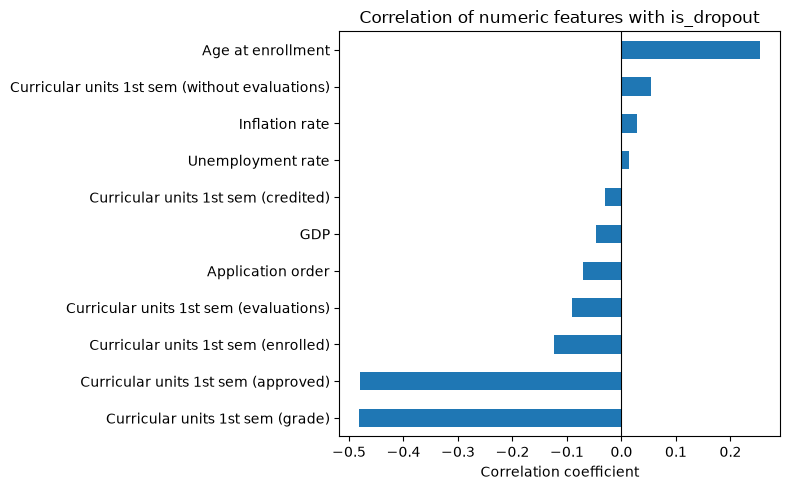

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Correlation of numeric columns with the target feature
plt.figure(figsize=(8, 5))
corr_with_target = df_encoded[numeric_cols + ["is_dropout"]].corr()["is_dropout"].sort_values(ascending=False)
corr_with_target.drop("is_dropout").sort_values().plot(kind="barh")
plt.title("Correlation of numeric features with is_dropout")
plt.xlabel("Correlation coefficient")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


- 1st-semester grade and units approved are by far the strongest
  predictors (both around -0.48) so students who perform well academically
  in their first semester are much less likely to drop out. This makes
 sense and confirms that academic performance, not demographics,
  carries most of the predictive signal in this dataset.
- Age at enrollment is the strongest positive signal (+0.25) so older
  students at the time of enrollment are somewhat more likely to drop out.
  This is the only demographic factor with a meaningful effect.
- Units enrolled and evaluations (-0.12, -0.09) show a moderate
  relationship. Students who take on fewer units, or sit fewer exams,
  trend slightly more toward dropping out, which could show that they are not engaged. 
- Everything else: macroeconomic context (unemployment, inflation, GDP),
  application order, credited units has almost no individual
  relationship with dropout (all under 0.07 in either direction). This
  doesn't necessarily mean these features are useless; it means they don't
  predict dropout on their own. They could still matter in combination
  with other features, which a single correlation score can't capture.

In [ ]:
#check relationship between binary features and the target

binary_check_cols = ["Scholarship holder", "Debtor", "Tuition fees up to date", 
                      "Displaced", "Gender", "Educational special needs", "International"]

for col in binary_check_cols:
    print(f"\n{col}:")
    print(df.groupby(col)["is_dropout"].mean())


Scholarship holder:
Scholarship holder
0    0.387068
1    0.121929
Name: is_dropout, dtype: float64

Debtor:
Debtor
0    0.282836
1    0.620278
Name: is_dropout, dtype: float64

Tuition fees up to date:
Tuition fees up to date
0    0.865530
1    0.247433
Name: is_dropout, dtype: float64

Displaced:
Displaced
0    0.376376
1    0.275763
Name: is_dropout, dtype: float64

Gender:
Gender
0    0.251046
1    0.450514
Name: is_dropout, dtype: float64

Educational special needs:
Educational special needs
0    0.321061
1    0.333333
Name: is_dropout, dtype: float64

International:
International
0    0.321975
1    0.290909
Name: is_dropout, dtype: float64


Financial circumstances have turned out to be one of the strongest predictors of dropout in this dataset. 
Students who are behind on tuition payments drop out at a rate of 86.6%, compared to just 24.7% for
those who are up to date. Students with outstanding debt drop out at 62.0%, versus 28.3% for those without debt.
Scholarship holders, on the other hand, drop out at only 12.2%, compared to 38.7% for non-scholarship students suggesting that financial support
meaningfully reduces dropout risk.

By contrast, being a displaced student, having educational special needs,
or being an international student showed almost no difference in dropout
rate between groups, meaning these factors don't appear to meaningfully
predict dropout on their own in this dataset.

Overall, this suggests that financial stability and not just academic
performance is one of the clearest drivers of dropout risk, and
institutions aiming to reduce dropout might get more value from financial
support programs (tuition flexibility, debt relief, scholarships) than from
academic interventions alone.

In [17]:
# Disengagement gap
df["sem1_disengagement_gap"] = df["Curricular units 1st sem (enrolled)"] - df["Curricular units 1st sem (evaluations)"]
print(df.groupby("is_dropout")["sem1_disengagement_gap"].describe())

             count      mean       std   min  25%  50%  75%  max
is_dropout                                                      
0           3003.0 -2.074925  2.476548 -27.0 -3.0 -1.0  0.0  0.0
1           1421.0 -1.930331  4.081399 -15.0 -5.0 -2.0  0.0  7.0


In [21]:
# Pass rate ratio (normalizes "approved" by how much a student actually attempted)
df["sem1_pass_rate"] = pd.to_numeric(
    df["Curricular units 1st sem (approved)"] / df["Curricular units 1st sem (evaluations)"].replace(0, float("nan")),
    errors="coerce"
)
print(df.groupby("is_dropout")["sem1_pass_rate"].describe())

             count      mean       std  min       25%       50%       75%  max
is_dropout                                                                    
0           2900.0  0.712992  0.251770  0.0  0.555556  0.750000  0.875000  1.0
1           1175.0  0.331870  0.304054  0.0  0.000000  0.285714  0.555556  1.0


In [19]:
# Financial risk score 
df["financial_risk_score"] = (
    (df["Debtor"] == 1).astype(int) +
    (df["Tuition fees up to date"] == 0).astype(int) +
    (df["Scholarship holder"] == 0).astype(int)
)
print(df.groupby("is_dropout")["financial_risk_score"].describe())
print(df.groupby("financial_risk_score")["is_dropout"].mean())  # dropout rate at each score level

             count      mean       std  min  25%  50%  75%  max
is_dropout                                                     
0           3003.0  0.765901  0.572065  0.0  0.0  1.0  1.0  3.0
1           1421.0  1.446868  0.809816  0.0  1.0  1.0  2.0  3.0
financial_risk_score
0    0.092742
1    0.292933
2    0.692469
3    0.887892
Name: is_dropout, dtype: float64


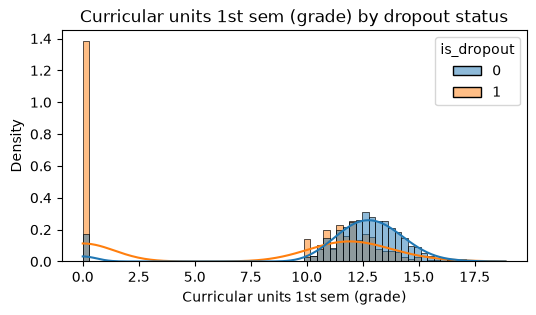

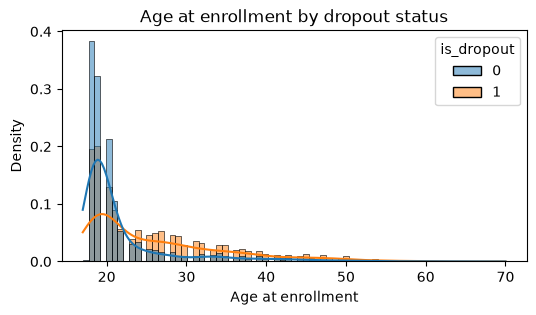

In [20]:
#Distributions of grade and age
for col in ["Curricular units 1st sem (grade)", "Age at enrollment"]:
    plt.figure(figsize=(6, 3))
    sns.histplot(data=df, x=col, hue="is_dropout", kde=True, stat="density", common_norm=False)
    plt.title(f"{col} by dropout status")
    plt.show()

Dropout students show a large spike at a grade of exactly 0, while non-dropout students cluster around 10-15.
This suggests many dropouts never received a grade at all likely because they disengaged before being evaluated, rather than attending and failing.
This suggests that a has_zero_grade variable could be good one.


Non-dropout students are heavily
concentrated around ages 18-20, while dropout students are more spread out
and skew slightly older. Confirms age as a real, if moderate, predictor.